# 1D Convolutional Neural Networks Tutorial

### About the data

Data for this exercise is from the [Human Activity Recognition Using Smartphones Data Set](https://archive.ics.uci.edu/ml/datasets/human+activity+recognition+using+smartphones) which is furnished by the University of California Irvine Machine Learning Repository.
<br><br>
In order to populate the dataset, subjects wore a smartphone that recorded their linear acceleration (using an accelerometer) and angular accelleration (using a gyroscope) while performing typical daily activity. After the data was collected, segments of each data recording were labeled based on the activity of the subject during that period. (This was possible by consulting video recordings.) Possible data labels in this dataset are: WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, and LAYING. <br><br>

The goal of our classifier will be to predict the label of a segment of recording based on accelerometer and gyroscope readings.

(Data details: there are two sets of x, y, z accelerations in each input sample, one for the sensor itself and another for the subject's body accelerations. Thus, there are 9 different signals recorded for each labeled datapoint-- 3 linear accelerations, 3 linear "body" accelerations, and 3 angular accelerations. All signals have a sample rate of 50 Hz.)


In [1]:
# Imports

#array/dataframe functions
import numpy as np
import pandas as pd

#file manipulations
import os

#data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#plotting functionality
import matplotlib.pyplot as plt
import matplotlib
#set default plotting fonts
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 16}

matplotlib.rc('font', **font)

import torch

### Read in data (using functions provided below)

Before we read in test/training data, we need to load two provided functions. (read_data_test() and read_data_train()) These functions just load in the data from a github repository into test and training datasets.

In [2]:
#Define functions to read in test/train data from files

def read_data_test():
  """ Read test data from github and store in numpy array"""

  # Fixed params
  n_class = 6
  n_steps = 128

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/y_test.txt'
  labels = pd.read_csv(label_path, header = None)

  list_of_channels = ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x',
  'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']

  X = np.zeros((len(labels), n_steps, len(list_of_channels)))

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/body_acc_x_test.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,0] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/body_acc_y_test.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,1] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/body_acc_z_test.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,2] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/body_gyro_x_test.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,3] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/body_gyro_y_test.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,4] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/body_gyro_z_test.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,5] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/total_acc_x_test.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,6] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/total_acc_y_test.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,7] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/total_acc_z_test.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,8] = dat_.to_numpy()


  # Return
  return X, labels[0].values, list_of_channels


def read_data_train():
  """ Read train data from github and store in numpy array"""

  # Fixed params
  n_class = 6
  n_steps = 128

  label_path ='https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/y_train.txt'
  labels = pd.read_csv(label_path, header = None)

  list_of_channels = ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x',
  'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']

  X = np.zeros((len(labels), n_steps, len(list_of_channels)))

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/body_acc_x_train.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,0] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/body_acc_y_train.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,1] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/body_acc_z_train.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,2] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/body_gyro_x_train.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,3] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/body_gyro_y_train.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,4] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/body_gyro_z_train.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,5] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/total_acc_x_train.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,6] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/total_acc_y_train.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,7] = dat_.to_numpy()

  label_path = 'https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/week2_conv1d/IntertialSignals/total_acc_z_train.txt'
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
  X[:,:,8] = dat_.to_numpy()


  # Return
  return X, labels[0].values, list_of_channels

In [3]:
#Call functions to load all data into variables

X_train, labels_train, list_ch_train = read_data_train()
X_test, labels_test, list_ch_test = read_data_test()

/tmp/ipykernel_1005/1691326751.py:75: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
/tmp/ipykernel_1005/1691326751.py:79: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
/tmp/ipykernel_1005/1691326751.py:83: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat_ = pd.read_csv(label_path, delim_whitespace = True, header = None)
/tmp/ipykernel_1005/1691326751.py:87: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dat_ = pd.read_csv(label_path, delim_whitespace = True, hea

In [4]:
#Print out the shape of the data to verify its size

print('X_train.shape:')
print(X_train.shape)
print('\n')

print('X_test.shape:')
print(X_test.shape)

X_train.shape:
(7352, 128, 9)


X_test.shape:
(2947, 128, 9)



### Explaining the shape of the data
Dimension 1: There are **7,352** recordings that are labeled as doing one of those activities <br>
Dimension 2: In each recording there are **128** time steps <br>
Dimension 3: At each timestep, there are sensor **9** values (3 values each for linear acceleration, linear "body" acceleration, and angular acceleration) <br>

### Plot signals from single data point

Text(0.5, 0.9, 'Example 6542, Activity: LAYING')

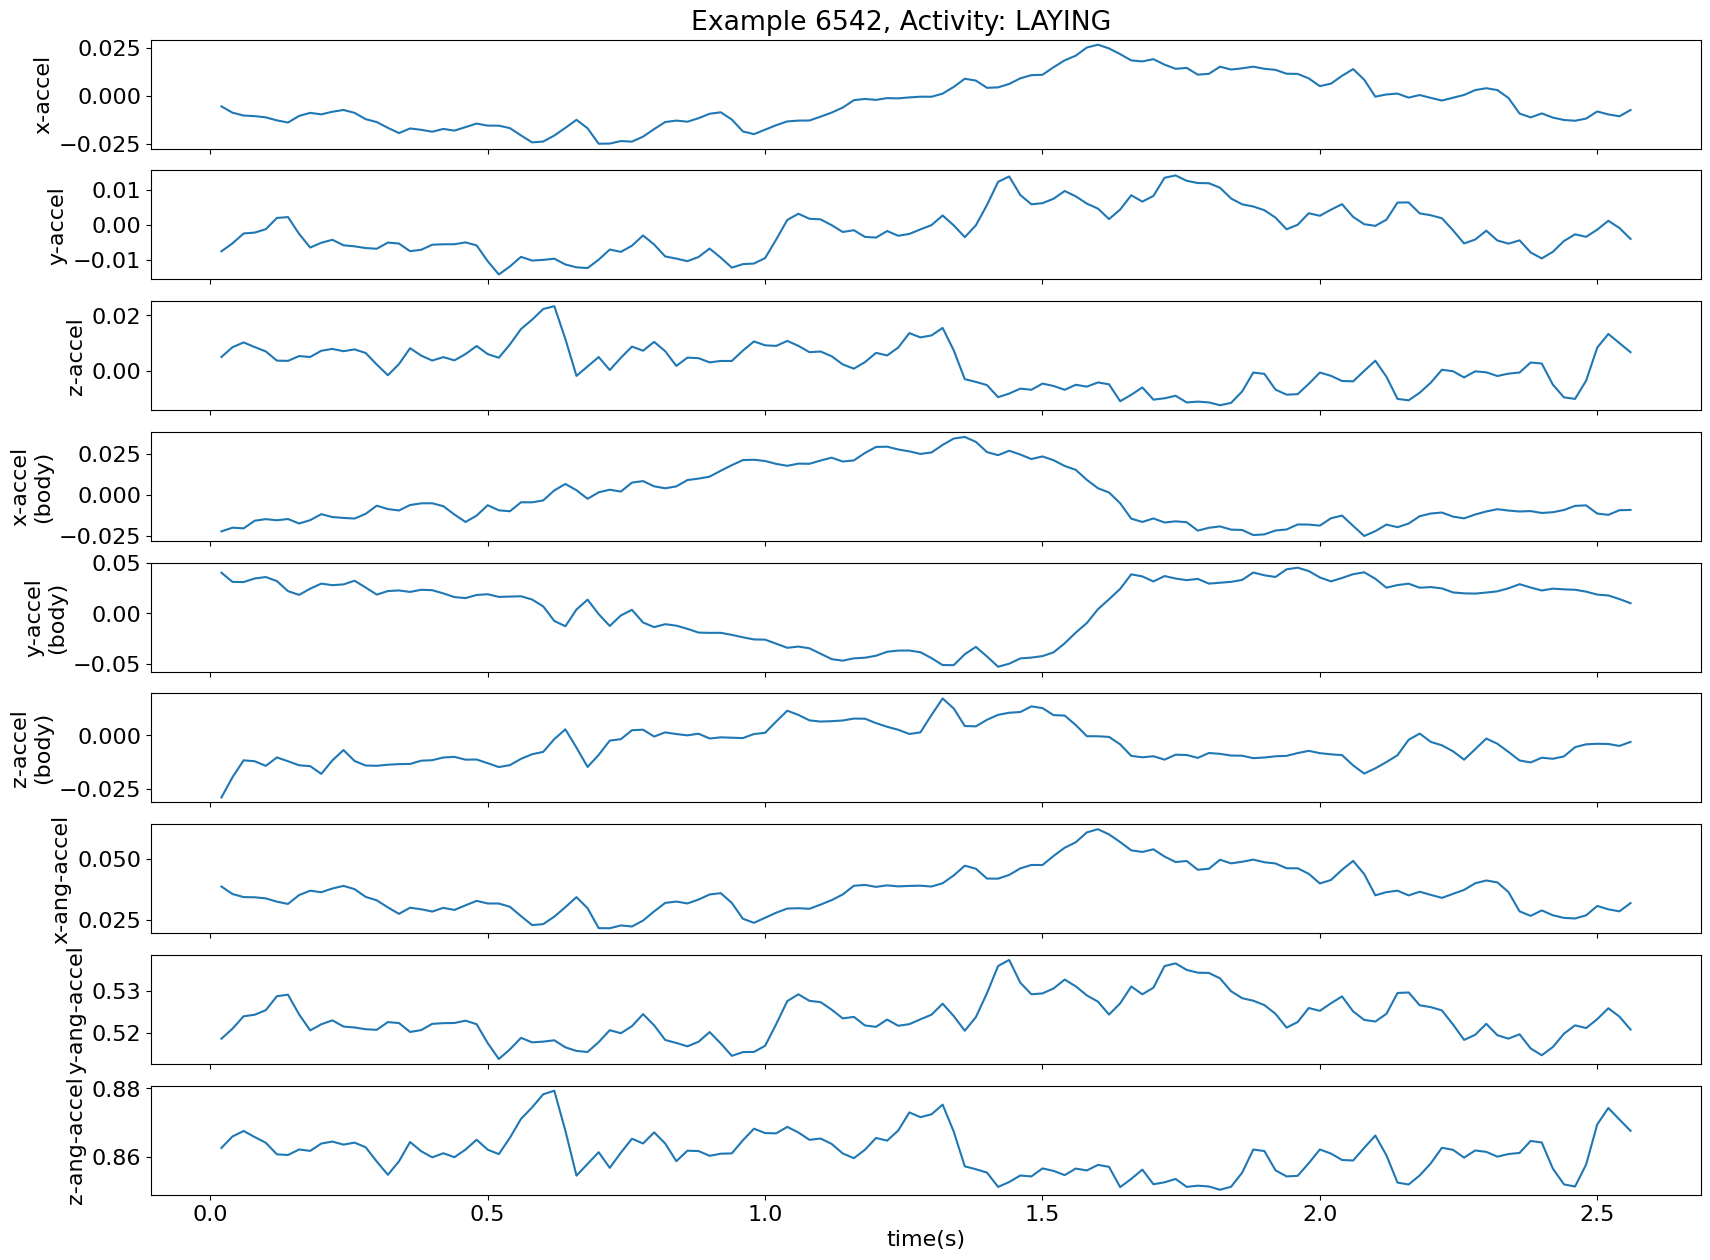

In [5]:
#Plot signals from a single data point to "see" signals data

#Get random sample number for plotting
sample_num = np.random.randint(0,X_train.shape[0]) #Get a random index
example_data_point = X_train[sample_num, :, :]
example_label_int = labels_train[sample_num]

#Define dictionaries to help label our plot

#Note that label integers actually vary from 1-6
labels2actions_dict = {1:'WALKING', 2: 'WALKING_UPSTAIRS', 3:'WALKING_DOWNSTAIRS',
                   4:'SITTING', 5: 'STANDING', 6: 'LAYING'}

signal_labels_dict = {0:'x-accel', 1: 'y-accel', 2:'z-accel',
                   3:'x-accel\n(body)', 4: 'y-accel\n(body)', 5: 'z-accel\n(body)',
                   6:'x-ang-accel', 7: 'y-ang-accel', 8: 'z-ang-accel'}

example_action = labels2actions_dict[example_label_int]

#Calculate time vector from sample rate (doesn't vary over dataset)
f_s = 50 # constant 50 Hz sampling rate
t_vector = np.linspace(start = 0.02, stop = 2.56 , num = 128)

#Make subplots for all signal channels
fig, axs = plt.subplots(example_data_point.shape[1], 1,
                        sharex = True,
                        figsize = (20, 15))

for signal_ind in range(example_data_point.shape[1]):
    axs[signal_ind].plot(t_vector, example_data_point[:, signal_ind])
    axs[signal_ind].set_ylabel(signal_labels_dict[signal_ind])

# label x-axis
axs[-1].set_xlabel('time(s)')

# set title based on what activity is being performed
plt.suptitle(f'Example {sample_num}, Activity: {example_action}', y = 0.9)


#### Why Convolutions?

Historically, neural networks were actually not very popular in ML. Many learning algorithms outperform neural networks on tabular datasets.

Neural networks rose to popularity when it was discovered that they performed well on datasets with a 'spatial' element. For example: images, text, and audio all have some spatial element to them.

In particular: it was convolutions that brought this hidden strength of neural networks to light by forcing networks to learn features derived from detecting spatial hierarchies and relationships. In many ways, modern deep learning would not exist without convolutions.

### Splitting data

In [6]:
#Split training data up so we can use part of it for a development set

#Below is a block to scale training and test data
#this would make sure that the magnitudes of all measurements are similar
#before we

## Uncomment this block to scale time series data
#(Performing this scaling will mean that the units of each datapoint are no
#longer in standard units)

'''
scaler = StandardScaler()
reshaped_X_train = X_train.reshape((X_train.shape[0]*X_train.shape[1], X_train.shape[2])).copy()
reshaped_X_test = X_test.reshape((X_test.shape[0]*X_test.shape[1], X_train.shape[2])).copy()

reshaped_X_train = scaler.fit_transform(reshaped_X_train)
reshaped_X_test = scaler.transform(reshaped_X_test)

X_train = reshaped_X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = reshaped_X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))
'''

#Note: In the split, we stratify based on training labels to ensure that within
#each label data is divided proportionately between the new training and
#validation sets

X_tr, X_vld, y_tr, y_vld = train_test_split(X_train, labels_train,
                                                stratify = labels_train, random_state = 123)

# Our labels are class indices from 1->6
# Pytorch is expecting 0 indexed class labels
y_tr = y_tr - 1
y_vld = y_vld - 1

# Pytorch Conv1D is expecting inputs of shape (batch size, channels, sequence)
# Ours is currently (batch, sequence, channel)
# So we have to transpose
X_tr = X_tr.transpose((0,2,1))
X_vld = X_vld.transpose((0,2,1))

### Define your model <br>

We'll be using Pytorch's `torch.nn.Conv1d()` implementation of 1-D convolution for signals data. See documentation [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv1d.html).

> #### Discussion question:
> Which is more powerful in terms of expressivity? Convolutions or linear layers?
> IE: does the set of all possible convolutions contain all possible linear layers?
>
><details>
>  <summary>Answer</summary>
>  
> Like regular linear layers, you can implement convolution as a matrix multiplication between weights and inputs. See [here](https://stackoverflow.com/questions/16798888/2-d-convolution-as-a-matrix-matrix-multiplication).
>
> This means that--theoretically speaking--there is nothing stopping a linear layer from just by chance learning a convolution operation.
>
>  
></details>

In [7]:
#Define neural network structure using Keras

import torch.nn as nn
model = nn.Sequential(
    nn.Conv1d(9, 18, 2, 1, padding='same'),
    nn.ReLU(),
    nn.MaxPool1d(18),
    nn.Flatten(),
    nn.Linear(126,6)
)

In [8]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 50
batch_size = 100

train = torch.utils.data.TensorDataset(
    torch.tensor(X_tr, dtype=torch.float32),
    torch.tensor(y_tr, dtype=torch.long)
)
train_loader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=False)

for epoch in range(epochs):
    for i, data in enumerate(train_loader):
        # Train loop
        model.train()
        inputs, labels = data

        # Pytorch keeps track of gradients across loops, so we need to zero it for each batch
        # We need to manually zero the gradient--reset it--every batch
        optimizer.zero_grad()

        outputs = model(inputs) # Get the model's output
        loss = criterion(outputs, labels) # Compute the loss
        preds = torch.argmax(outputs,dim=1)

        # For monitoring
        tr_loss = loss.item()
        tr_acc = torch.sum(preds==labels)/len(labels)

        loss.backward() # Backpropagate to compute gradient
        optimizer.step() # Update the parameters, according to chosen optimizer algorithm
    # Validation loop
    model.eval()
    inputs, labels = torch.tensor(X_vld, dtype=torch.float32), torch.tensor(y_vld, dtype=torch.long)

    outputs = model(inputs)
    preds = torch.argmax(outputs,dim=1)

    val_loss = criterion(outputs, labels).item()
    val_acc = torch.sum(preds==labels)/len(labels)

    print(('Epoch #%d\t Training Loss: %.2f\tTraining Accuracy: %.2f\t'
         'Validation Loss: %.2f\tValidation Accuracy: %.2f')
         % (epoch + 1, tr_loss, tr_acc,
         val_loss, val_acc))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1024.)
  return F.conv1d(


Epoch #1	 Training Loss: 0.33	Training Accuracy: 0.93	Validation Loss: 0.29	Validation Accuracy: 0.92
Epoch #2	 Training Loss: 0.17	Training Accuracy: 0.93	Validation Loss: 0.20	Validation Accuracy: 0.92
Epoch #3	 Training Loss: 0.15	Training Accuracy: 0.93	Validation Loss: 0.17	Validation Accuracy: 0.93
Epoch #4	 Training Loss: 0.13	Training Accuracy: 0.93	Validation Loss: 0.14	Validation Accuracy: 0.94
Epoch #5	 Training Loss: 0.13	Training Accuracy: 0.93	Validation Loss: 0.13	Validation Accuracy: 0.95
Epoch #6	 Training Loss: 0.13	Training Accuracy: 0.93	Validation Loss: 0.13	Validation Accuracy: 0.95
Epoch #7	 Training Loss: 0.13	Training Accuracy: 0.93	Validation Loss: 0.12	Validation Accuracy: 0.95
Epoch #8	 Training Loss: 0.13	Training Accuracy: 0.93	Validation Loss: 0.12	Validation Accuracy: 0.95
Epoch #9	 Training Loss: 0.14	Training Accuracy: 0.93	Validation Loss: 0.12	Validation Accuracy: 0.95
Epoch #10	 Training Loss: 0.14	Training Accuracy: 0.93	Validation Loss: 0.12	Valid

### Evaluate model on test set

In [9]:
#Evaluate model on test set
X_test = X_test.transpose((0,2,1))
y_test = labels_test - 1

model.eval()
inputs, labels = torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)

outputs = model(inputs)
preds = torch.argmax(outputs,dim=1)

test_loss = criterion(outputs, labels).item()
test_acc = torch.sum(preds==labels)/len(labels)

print(f'Test loss: {test_loss:.2f}, Test accuracy: {test_acc:.2f}')

Test loss: 0.69, Test accuracy: 0.91
